## Symulator tomografu komputerowego

In [43]:
from skimage import io, color
from skimage.draw import line_nd
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

from pydicom.dataset import Dataset, FileDataset
from skimage import img_as_uint
from skimage.exposure import rescale_intensity

#### Transformata Radona (tworzenie sinogramu)

In [4]:
def sample_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)
    
    values = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            values.append(img[r, c])
    
    return np.sum(values)

In [5]:
def radon_transformation(img, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    angles = np.deg2rad(np.arange(0, 360, alpha))

    sinogram = []

    if iterations is None:
        iterations = len(angles)
        
    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(img, xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)
    
    return np.array(sinogram)

#### Filtrowanie sinogramu

In [63]:
def filter(sinogram):
    filtered_sinogram = []
    kernel = []

    for k in range(-10, 11):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)

    # kernel = kernel[0:len(kernel) // 2]

    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))
    
    return np.array(filtered_sinogram)

#### Odwrotna transformata Radona (rekonstrukcja obrazu)

In [7]:
def get_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)

    points = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            points.append((c, r))

    return points

In [69]:
def inverse_radon_transformation(img, sinogram, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    reconstructed_img = np.zeros((h, w))
    
    angles = np.deg2rad(np.arange(0, 360, alpha))
    
    if iterations is None:
        iterations = len(angles)
        
    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]
        
        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            line = get_line(img, xE, yE, xD, yD)

            val = sinogram[iteration, i]

            for x, y in line:
                if 0 <= x < h and 0 <= y < w:
                    reconstructed_img[y, x] += val

    img_min = np.min(reconstructed_img)
    img_max = np.max(reconstructed_img)

    reconstructed_img = (reconstructed_img - img_min) / (img_max - img_min)

    return reconstructed_img

#### Zapis pliku DICOM

In [44]:
def convert_image_to_uint16(img):
    # Przeskalowanie do zakresu 0.0 - 1.0 i konwersja na 16-bit unsigned integer
    return img_as_uint(rescale_intensity(img, out_range=(0.0, 1.0)))

def save_as_dicom(file_name, img, patient_data):
    img_converted = convert_image_to_uint16(img)
    
    # Populate required values for file meta information
    meta = Dataset()
    meta.MediaStorageSOPClassUID = pydicom._storage_sopclass_uids.CTImageStorage
    meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
    meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian  

    ds = FileDataset(None, {}, preamble=b"\0" * 128)
    ds.file_meta = meta

    ds.is_little_endian = True
    ds.is_implicit_VR = False

    ds.SOPClassUID = pydicom._storage_sopclass_uids.CTImageStorage
    ds.SOPInstanceUID = meta.MediaStorageSOPInstanceUID
    
    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]
    
    ds.Modality = "CT"
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.FrameOfReferenceUID = pydicom.uid.generate_uid()

    ds.BitsStored = 16
    ds.BitsAllocated = 16
    ds.SamplesPerPixel = 1
    ds.HighBit = 15

    ds.ImagesInAcquisition = 1
    ds.InstanceNumber = 1

    ds.Rows, ds.Columns = img_converted.shape

    ds.ImageType = r"ORIGINAL\PRIMARY\AXIAL"

    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.PixelRepresentation = 0

    pydicom.dataset.validate_file_meta(ds.file_meta, enforce_standard=True)

    ds.PixelData = img_converted.tobytes()

    ds.save_as(file_name, write_like_original=False)

#### Wczytywanie obrazu

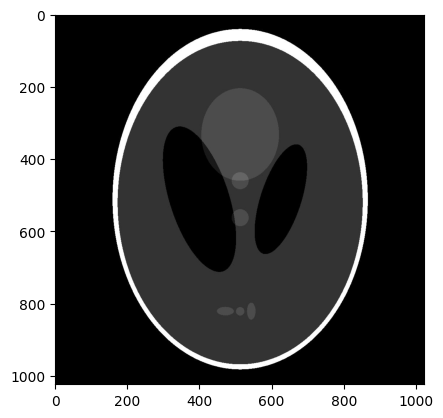

In [58]:
img = io.imread("img/Shepp_logan.jpg")

if len(img.shape) == 3:
    img = color.rgb2gray(img)

plt.imshow(img, cmap='gray')
plt.show()

#### Wyświetlanie wyników

In [61]:
def interactive_ct(alpha, n, phi_deg, progress=100, useFilter=True):
    phi_rad = np.deg2rad(phi_deg)

    total_iterations = len(np.arange(0, 360, alpha))
    current_iterations = int(total_iterations * (progress / 100))

    sinogram = radon_transformation(img, alpha, n, phi_rad, current_iterations)

    if useFilter:
        sinogram = filter(sinogram)

    global reconstructed_img 
    reconstructed_img = inverse_radon_transformation(img, sinogram, alpha, n, phi_rad, current_iterations)

    if np.max(reconstructed_img) > 0:
        reconstructed_img = reconstructed_img / np.max(reconstructed_img)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(20, 6),
        gridspec_kw={'width_ratios': [1, 1.3, 1]}
    )
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Obraz wejściowy")
    axes[0].axis('off')
    
    axes[1].imshow(sinogram, cmap='gray')
    axes[1].set_title("Sinogram")
    
    axes[2].imshow(reconstructed_img, cmap='gray')
    axes[2].set_title(f"Zrekonstruowany obraz")
    axes[2].axis('off')

    save_as_dicom('patient_45.dcm', reconstructed_img, {'PatientName': 'Scout', 'PatientID': '45', 'ImageComments': 'test'})
    
    plt.show()

In [ ]:
interact(
    interactive_ct, 
    alpha=IntSlider(min=1, max=10, step=1, value=4, description='Krok (deg):'),
    n=IntSlider(min=90, max=360, step=10, value=180, description='Detektory:'),
    phi_deg=IntSlider(min=45, max=270, step=15, value=90, description='Rozpiętość:'),
    progress=IntSlider(min=2, max=100, step=2, value=100, description='Postęp %:'),
    useFilter = True
)

interactive(children=(IntSlider(value=4, description='Krok (deg):', max=10, min=1), IntSlider(value=180, descr…

<function __main__.interactive_ct(alpha, n, phi_deg, progress=100, useFilter=True)>

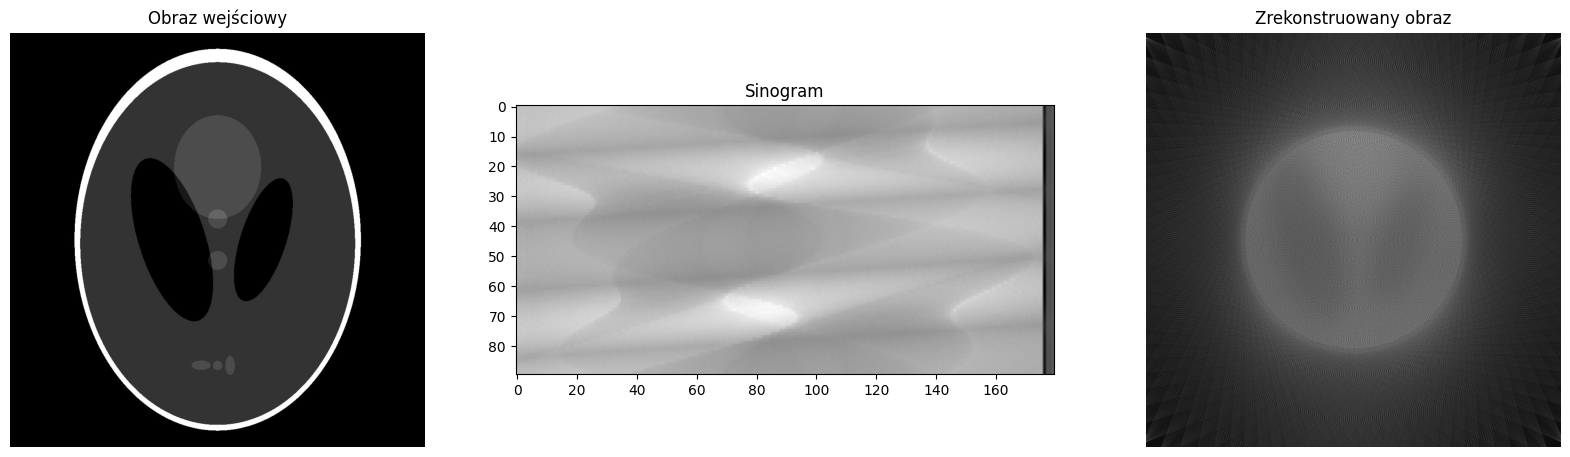

In [37]:
interactive_ct(4, 180, 90, 100, True)